In [ ]:
!pip install polars==0.17.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 32.6 MB/s eta 0:00:00
  Attempting uninstall: polars
    Found existing installation: polars 1.35.2
    Uninstalling polars-1.35.2:
      Successfully uninstalled polars-1.35.2


In [39]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
course_file_df = pl.read_csv("course_file.csv", has_header = True)

In [6]:
course_file_df.head()

date_time,userid,domain,dlbytes,ulbytes,clientip,serverip,country,txn_time,http_method,user_agent,platform
str,i64,str,i64,i64,str,str,str,f64,str,str,str
"""2023-10-04 11:37:11""",7773153683656,"""ryan-wells.co.uk""",872807,741526,"""142.132.219.110""","""62.42.184.180""","""England""",2.33,"""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-04 12:17:07""",1886351675683,"""hopkins.org""",50898,529504,"""184.205.48.78""","""152.123.41.39""","""Wales""",1.2,"""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-02 23:25:12""",1597721345356,"""evans.com""",964276,952420,"""189.30.60.163""","""68.171.236.18""","""Scotland""",1.32,"""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux"""
"""2023-10-03 09:43:11""",9766845800247,"""kelly.com""",212529,811887,"""13.144.79.35""","""63.141.80.109""","""England""",2.58,"""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android"""
"""2023-10-01 08:16:46""",1546762097287,"""richardson-walker.biz""",553626,901428,"""143.74.163.248""","""26.253.17.223""","""Wales""",1.53,"""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows"""


In [7]:
print(course_file_df.shape)

(100000, 12)


In [8]:
print(course_file_df.describe())

shape: (9, 13)
┌────────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬──────────┐
│ statistic  ┆ date_time ┆ userid    ┆ domain    ┆ … ┆ txn_time ┆ http_meth ┆ user_agen ┆ platform │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---      ┆ od        ┆ t         ┆ ---      │
│ str        ┆ str       ┆ f64       ┆ str       ┆   ┆ f64      ┆ ---       ┆ ---       ┆ str      │
│            ┆           ┆           ┆           ┆   ┆          ┆ str       ┆ str       ┆          │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪══════════╡
│ count      ┆ 100000    ┆ 100000.0  ┆ 100000    ┆ … ┆ 100000.0 ┆ 100000    ┆ 100000    ┆ 100000   │
│ null_count ┆ 0         ┆ 0.0       ┆ 0         ┆ … ┆ 0.0      ┆ 0         ┆ 0         ┆ 0        │
│ mean       ┆ null      ┆ 5.0101e12 ┆ null      ┆ … ┆ 1.498052 ┆ null      ┆ null      ┆ null     │
│ std        ┆ null      ┆ 2.8983e12 ┆ null      ┆ … ┆ 0.866925 ┆ null      

In [9]:
custom_schema = {
    'date_time': pl.Utf8,
    'userid': pl.Utf8,
    'domain': pl.Utf8,
    'dlbytes': pl.Utf8,
    'ulbytes': pl.Utf8,
    'clientip': pl.Utf8,
    'serverip': pl.Utf8,
    'country': pl.Utf8,
    'txn_time': pl.Utf8,
    'http_method': pl.Utf8,
    'user_agent': pl.Utf8,
    'platform': pl.Utf8,
}

In [10]:
course_file_df = pl.read_csv("course_file.csv", has_header = True, dtypes = custom_schema)

/tmp/ipykernel_634/3334629787.py:1: DeprecationWarning: the argument `dtypes` for `read_csv` is deprecated. It was renamed to `schema_overrides` in version 0.20.31.
  course_file_df = pl.read_csv("course_file.csv", has_header = True, dtypes = custom_schema)


In [11]:
course_file_df_no_nulls = course_file_df.filter((course_file_df["date_time"].is_not_null()) & (course_file_df["userid"].is_not_null()))

In [12]:
course_file_df_no_nulls.head()

date_time,userid,domain,dlbytes,ulbytes,clientip,serverip,country,txn_time,http_method,user_agent,platform
str,str,str,str,str,str,str,str,str,str,str,str
"""2023-10-04 11:37:11""","""7773153683656""","""ryan-wells.co.uk""","""872807""","""741526""","""142.132.219.110""","""62.42.184.180""","""England""","""2.33""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-04 12:17:07""","""1886351675683""","""hopkins.org""","""50898""","""529504""","""184.205.48.78""","""152.123.41.39""","""Wales""","""1.2""","""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-02 23:25:12""","""1597721345356""","""evans.com""","""964276""","""952420""","""189.30.60.163""","""68.171.236.18""","""Scotland""","""1.32""","""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux"""
"""2023-10-03 09:43:11""","""9766845800247""","""kelly.com""","""212529""","""811887""","""13.144.79.35""","""63.141.80.109""","""England""","""2.58""","""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android"""
"""2023-10-01 08:16:46""","""1546762097287""","""richardson-walker.biz""","""553626""","""901428""","""143.74.163.248""","""26.253.17.223""","""Wales""","""1.53""","""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows"""


In [13]:
course_file_df_no_nulls_2 = course_file_df.drop_nulls(subset = ['date_time', 'userid', 'domain'])

In [14]:
course_file_df.with_columns(pl.col("userid").fill_null(pl.lit(22)))

date_time,userid,domain,dlbytes,ulbytes,clientip,serverip,country,txn_time,http_method,user_agent,platform
str,str,str,str,str,str,str,str,str,str,str,str
"""2023-10-04 11:37:11""","""7773153683656""","""ryan-wells.co.uk""","""872807""","""741526""","""142.132.219.110""","""62.42.184.180""","""England""","""2.33""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-04 12:17:07""","""1886351675683""","""hopkins.org""","""50898""","""529504""","""184.205.48.78""","""152.123.41.39""","""Wales""","""1.2""","""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-02 23:25:12""","""1597721345356""","""evans.com""","""964276""","""952420""","""189.30.60.163""","""68.171.236.18""","""Scotland""","""1.32""","""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux"""
"""2023-10-03 09:43:11""","""9766845800247""","""kelly.com""","""212529""","""811887""","""13.144.79.35""","""63.141.80.109""","""England""","""2.58""","""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android"""
"""2023-10-01 08:16:46""","""1546762097287""","""richardson-walker.biz""","""553626""","""901428""","""143.74.163.248""","""26.253.17.223""","""Wales""","""1.53""","""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows"""
…,…,…,…,…,…,…,…,…,…,…,…
"""2023-10-02 19:33:09""","""4509087590322""","""berry.co.uk""","""369884""","""390349""","""74.141.235.40""","""77.34.183.69""","""Scotland""","""2.95""","""HTTP""","""Mozilla/5.0 (iPhone; CPU iPhon…","""Windows"""
"""2023-10-01 19:24:08""","""8113107789552""","""fox-baker.biz""","""903806""","""722531""","""208.43.30.51""","""167.168.187.4""","""Ireland""","""0.04""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-03 15:28:12""","""0346350168972""","""phillips.com""","""960762""","""239623""","""201.234.188.11""","""126.136.250.206""","""Scotland""","""0.76""","""HTTPS""","""Opera/8.86.(X11; Linux x86_64;…","""Linux"""


In [32]:
course_file_df = course_file_df.with_columns(pl.col("dlbytes").cast(pl.Int64))
course_file_df.with_columns(pl.col("dlbytes").fill_null(pl.median("dlbytes"))).head(5)

date_time,userid,domain,dlbytes,ulbytes,clientip,serverip,country,txn_time,http_method,user_agent,platform
str,str,str,f64,i64,str,str,str,str,str,str,str
"""2023-10-04 11:37:11""","""7773153683656""","""ryan-wells.co.uk""",872807.0,741526,"""142.132.219.110""","""62.42.184.180""","""England""","""2.33""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-04 12:17:07""","""1886351675683""","""hopkins.org""",50898.0,529504,"""184.205.48.78""","""152.123.41.39""","""Wales""","""1.2""","""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-02 23:25:12""","""1597721345356""","""evans.com""",964276.0,952420,"""189.30.60.163""","""68.171.236.18""","""Scotland""","""1.32""","""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux"""
"""2023-10-03 09:43:11""","""9766845800247""","""kelly.com""",212529.0,811887,"""13.144.79.35""","""63.141.80.109""","""England""","""2.58""","""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android"""
"""2023-10-01 08:16:46""","""1546762097287""","""richardson-walker.biz""",553626.0,901428,"""143.74.163.248""","""26.253.17.223""","""Wales""","""1.53""","""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows"""


In [16]:
course_file_df.fill_nan(344)

date_time,userid,domain,dlbytes,ulbytes,clientip,serverip,country,txn_time,http_method,user_agent,platform
str,str,str,str,str,str,str,str,str,str,str,str
"""2023-10-04 11:37:11""","""7773153683656""","""ryan-wells.co.uk""","""872807""","""741526""","""142.132.219.110""","""62.42.184.180""","""England""","""2.33""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-04 12:17:07""","""1886351675683""","""hopkins.org""","""50898""","""529504""","""184.205.48.78""","""152.123.41.39""","""Wales""","""1.2""","""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-02 23:25:12""","""1597721345356""","""evans.com""","""964276""","""952420""","""189.30.60.163""","""68.171.236.18""","""Scotland""","""1.32""","""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux"""
"""2023-10-03 09:43:11""","""9766845800247""","""kelly.com""","""212529""","""811887""","""13.144.79.35""","""63.141.80.109""","""England""","""2.58""","""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android"""
"""2023-10-01 08:16:46""","""1546762097287""","""richardson-walker.biz""","""553626""","""901428""","""143.74.163.248""","""26.253.17.223""","""Wales""","""1.53""","""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows"""
…,…,…,…,…,…,…,…,…,…,…,…
"""2023-10-02 19:33:09""","""4509087590322""","""berry.co.uk""","""369884""","""390349""","""74.141.235.40""","""77.34.183.69""","""Scotland""","""2.95""","""HTTP""","""Mozilla/5.0 (iPhone; CPU iPhon…","""Windows"""
"""2023-10-01 19:24:08""","""8113107789552""","""fox-baker.biz""","""903806""","""722531""","""208.43.30.51""","""167.168.187.4""","""Ireland""","""0.04""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-03 15:28:12""","""0346350168972""","""phillips.com""","""960762""","""239623""","""201.234.188.11""","""126.136.250.206""","""Scotland""","""0.76""","""HTTPS""","""Opera/8.86.(X11; Linux x86_64;…","""Linux"""


In [17]:
course_file_df.select(pl.col("*").exclude("dlbytes", "ulbytes")).head(5)

date_time,userid,domain,clientip,serverip,country,txn_time,http_method,user_agent,platform
str,str,str,str,str,str,str,str,str,str
"""2023-10-04 11:37:11""","""7773153683656""","""ryan-wells.co.uk""","""142.132.219.110""","""62.42.184.180""","""England""","""2.33""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-04 12:17:07""","""1886351675683""","""hopkins.org""","""184.205.48.78""","""152.123.41.39""","""Wales""","""1.2""","""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-02 23:25:12""","""1597721345356""","""evans.com""","""189.30.60.163""","""68.171.236.18""","""Scotland""","""1.32""","""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux"""
"""2023-10-03 09:43:11""","""9766845800247""","""kelly.com""","""13.144.79.35""","""63.141.80.109""","""England""","""2.58""","""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android"""
"""2023-10-01 08:16:46""","""1546762097287""","""richardson-walker.biz""","""143.74.163.248""","""26.253.17.223""","""Wales""","""1.53""","""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows"""


In [ ]:
course_file_df.select(pl.col("dlbytes"), pl.col("ulbytes")).head(5)

dlbytes,ulbytes
str,str
"""872807""","""741526"""
"""50898""","""529504"""
"""964276""","""952420"""
"""212529""","""811887"""
"""553626""","""901428"""


In [18]:
course_file_df.select(pl.all()).head(5)

date_time,userid,domain,dlbytes,ulbytes,clientip,serverip,country,txn_time,http_method,user_agent,platform
str,str,str,str,str,str,str,str,str,str,str,str
"""2023-10-04 11:37:11""","""7773153683656""","""ryan-wells.co.uk""","""872807""","""741526""","""142.132.219.110""","""62.42.184.180""","""England""","""2.33""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-04 12:17:07""","""1886351675683""","""hopkins.org""","""50898""","""529504""","""184.205.48.78""","""152.123.41.39""","""Wales""","""1.2""","""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android"""
"""2023-10-02 23:25:12""","""1597721345356""","""evans.com""","""964276""","""952420""","""189.30.60.163""","""68.171.236.18""","""Scotland""","""1.32""","""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux"""
"""2023-10-03 09:43:11""","""9766845800247""","""kelly.com""","""212529""","""811887""","""13.144.79.35""","""63.141.80.109""","""England""","""2.58""","""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android"""
"""2023-10-01 08:16:46""","""1546762097287""","""richardson-walker.biz""","""553626""","""901428""","""143.74.163.248""","""26.253.17.223""","""Wales""","""1.53""","""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows"""


In [19]:
course_file_df = course_file_df.with_columns(pl.col("dlbytes").cast(pl.Int64), pl.col("ulbytes").cast(pl.Int64))

In [20]:
course_file_df.select(pl.col("dlbytes"), (pl.col("dlbytes") *5).alias("calculated_dlbytes")).head(6)

dlbytes,calculated_dlbytes
i64,i64
872807,4364035
50898,254490
964276,4821380
212529,1062645
553626,2768130
43595,217975


In [21]:
course_file_df.select(
    pl.col("dlbytes"), (pl.col("dlbytes") *5).alias("calculated_dlbytes"),
    pl.col("ulbytes"), (pl.col("dlbytes") *5).alias("calculated_ulbytes")
).head(6)

dlbytes,calculated_dlbytes,ulbytes,calculated_ulbytes
i64,i64,i64,i64
872807,4364035,741526,4364035
50898,254490,529504,254490
964276,4821380,952420,4821380
212529,1062645,811887,1062645
553626,2768130,901428,2768130
43595,217975,77597,217975


In [22]:
course_file_df.select(
    pl.col("dlbytes"), (pl.col("dlbytes") * 5).alias("calculated_dlbytes"),
    pl.col("ulbytes"), (pl.col("dlbytes") / 5.7).cast(pl.Float64).round(2).alias("calculated_ulbytes")
).head(6)

dlbytes,calculated_dlbytes,ulbytes,calculated_ulbytes
i64,i64,i64,f64
872807,4364035,741526,153124.04
50898,254490,529504,8929.47
964276,4821380,952420,169171.23
212529,1062645,811887,37285.79
553626,2768130,901428,97127.37
43595,217975,77597,7648.25


In [23]:
course_file_df.select(
   pl.col("dlbytes"),
   pl
    .when(pl.col("dlbytes") > 50000)
    .then(pl.lit("large"))
    .otherwise(pl.lit("small"))
   .alias("When_Statement_Test")
).head(5)

dlbytes,When_Statement_Test
i64,str
872807,"""large"""
50898,"""large"""
964276,"""large"""
212529,"""large"""
553626,"""large"""


In [ ]:
course_file_df.select(
    pl.col("country"),
    pl
      .when(pl.col("country") == "England")
      .then(pl.lit(True))
      .otherwise(pl.lit(False))
    .alias("Is_It_England")
).head(6)

country,Is_It_England
str,bool
"""England""",true
"""Wales""",false
"""Scotland""",false
"""England""",true
"""Wales""",false
"""England""",true


In [24]:
platform = ["Android", "IOS", "Linux", "Windows"]

In [25]:
course_file_df.select(
    pl.col("platform"),
    pl.col("dlbytes"),
    pl
      .when((pl.col("platform").is_in(platform)) & (pl.col("dlbytes") > 5000))
      .then(pl.lit(1))
      .otherwise(pl.lit(0))
      .alias("Platforms_When")
).head(5)

platform,dlbytes,Platforms_When
str,i64,i32
"""Android""",872807,1
"""Android""",50898,1
"""Linux""",964276,1
"""Android""",212529,1
"""Windows""",553626,1


In [33]:
course_file_df.select(
    pl.col("ulbytes"),
    pl.col("dlbytes"),
    pl
      .when((pl.col("ulbytes") > 500000) & (pl.col("dlbytes") > 500000))
      .then(pl.lit("Large"))
      .when((pl.col("ulbytes") > 25000) & (pl.col("dlbytes") > 25000)) # Дужки виправлено
      .then(pl.lit("medium"))
      .otherwise(pl.lit("small"))
      .alias("Transaction_Size")
).head(5)

ulbytes,dlbytes,Transaction_Size
i64,i64,str
741526,872807,"""Large"""
529504,50898,"""medium"""
952420,964276,"""Large"""
811887,212529,"""medium"""
901428,553626,"""Large"""


In [27]:
def calculate_bytes(row):
  try:
    dlbytes = int(row[3])
    ulbytes = int(row[4])
    return dlbytes + ulbytes
  except:
    return 1

In [40]:
course_file_df.with_columns((pl.col("dlbytes").cast(pl.Int64) + pl.col("ulbytes").cast(pl.Int64)).alias("total_bytes")).head(5)

date_time,userid,domain,dlbytes,ulbytes,clientip,serverip,country,txn_time,http_method,user_agent,platform,total_bytes
str,str,str,i64,i64,str,str,str,str,str,str,str,i64
"""2023-10-04 11:37:11""","""7773153683656""","""ryan-wells.co.uk""",872807,741526,"""142.132.219.110""","""62.42.184.180""","""England""","""2.33""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android""",1614333
"""2023-10-04 12:17:07""","""1886351675683""","""hopkins.org""",50898,529504,"""184.205.48.78""","""152.123.41.39""","""Wales""","""1.2""","""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android""",580402
"""2023-10-02 23:25:12""","""1597721345356""","""evans.com""",964276,952420,"""189.30.60.163""","""68.171.236.18""","""Scotland""","""1.32""","""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux""",1916696
"""2023-10-03 09:43:11""","""9766845800247""","""kelly.com""",212529,811887,"""13.144.79.35""","""63.141.80.109""","""England""","""2.58""","""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android""",1024416
"""2023-10-01 08:16:46""","""1546762097287""","""richardson-walker.biz""",553626,901428,"""143.74.163.248""","""26.253.17.223""","""Wales""","""1.53""","""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows""",1455054


In [29]:
def makemilliseconds(row):
  try:
    txn_time = row[8]
    makemilliseconds = txn_time * 1000
    return makemilliseconds
  except:
    return 1

In [41]:
course_file_df.with_columns((pl.col("txn_time").cast(pl.Float64) * 1000).alias("txn_time_ms")).head(5)

date_time,userid,domain,dlbytes,ulbytes,clientip,serverip,country,txn_time,http_method,user_agent,platform,txn_time_ms
str,str,str,i64,i64,str,str,str,str,str,str,str,f64
"""2023-10-04 11:37:11""","""7773153683656""","""ryan-wells.co.uk""",872807,741526,"""142.132.219.110""","""62.42.184.180""","""England""","""2.33""","""HTTPS""","""Mozilla/5.0 (Windows; U; Windo…","""Android""",2330.0
"""2023-10-04 12:17:07""","""1886351675683""","""hopkins.org""",50898,529504,"""184.205.48.78""","""152.123.41.39""","""Wales""","""1.2""","""HTTP""","""Mozilla/5.0 (Windows; U; Windo…","""Android""",1200.0
"""2023-10-02 23:25:12""","""1597721345356""","""evans.com""",964276,952420,"""189.30.60.163""","""68.171.236.18""","""Scotland""","""1.32""","""HTTP""","""Mozilla/5.0 (Windows 98; Win 9…","""Linux""",1320.0
"""2023-10-03 09:43:11""","""9766845800247""","""kelly.com""",212529,811887,"""13.144.79.35""","""63.141.80.109""","""England""","""2.58""","""HTTPS""","""Opera/8.54.(X11; Linux i686; v…","""Android""",2580.0
"""2023-10-01 08:16:46""","""1546762097287""","""richardson-walker.biz""",553626,901428,"""143.74.163.248""","""26.253.17.223""","""Wales""","""1.53""","""HTTP""","""Mozilla/5.0 (Macintosh; Intel …","""Windows""",1530.0


In [38]:
course_file_df.select(
    pl.sum("dlbytes").alias("Total_DL_Bytes"),
    pl.min("dlbytes").alias("Min_DL_Bytes"),
    pl.max("dlbytes").alias("Max_DL_Bytes"),
    pl.std("dlbytes").alias("Standart_Deviation_DL_Bytes"),
    pl.median("dlbytes").alias("Median_DL_Bytes"),
    pl.mean("dlbytes").alias("Mean_DL_Bytes"),
    pl.first("dlbytes").alias("First_DL_Bytes"),
)

Total_DL_Bytes,Min_DL_Bytes,Max_DL_Bytes,Standart_Deviation_DL_Bytes,Median_DL_Bytes,Mean_DL_Bytes,First_DL_Bytes
i64,i64,i64,f64,f64,f64,i64
49999358573,61,999994,288565.822961,499479.5,499993.58573,872807


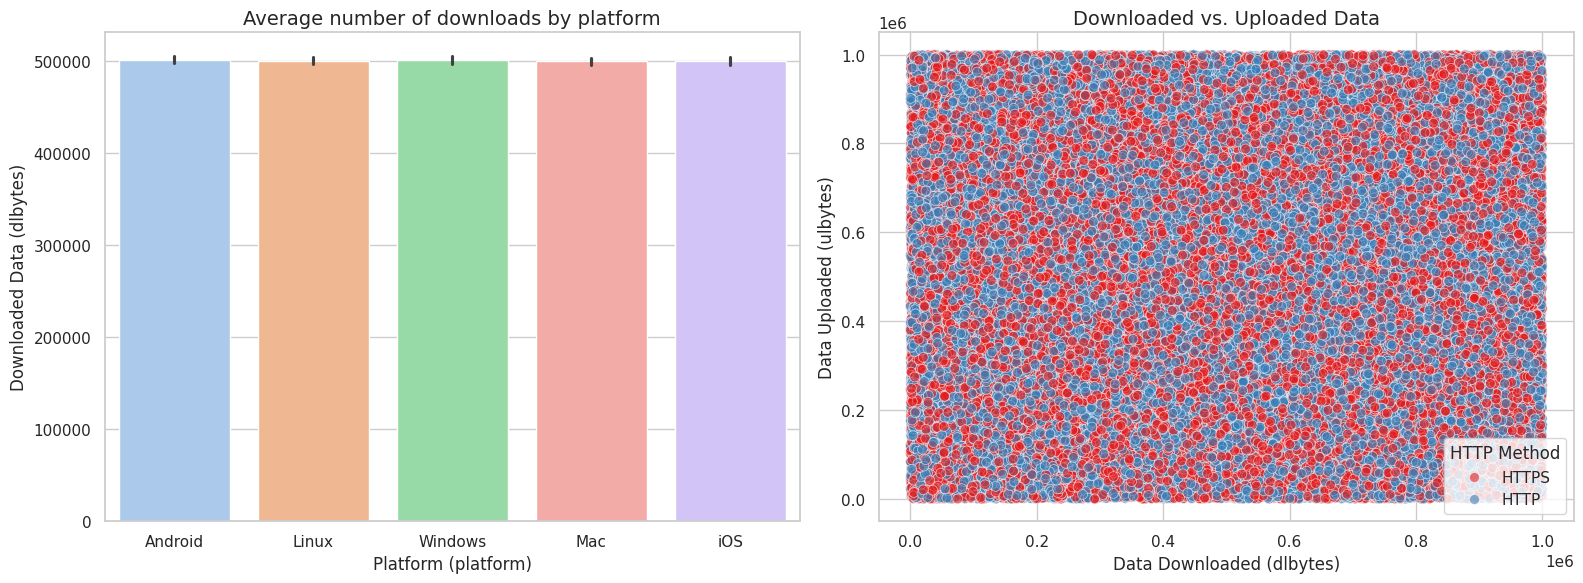

In [58]:
plot_df = course_file_df.with_columns([
    pl.col("dlbytes").cast(pl.Float64, strict = False),
    pl.col("ulbytes").cast(pl.Float64, strict = False)
]).drop_nulls(subset=["dlbytes", "ulbytes", "platform"]).to_pandas()

sns.set_theme(style = "whitegrid")

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

sns.barplot(data = plot_df, x = 'platform', y = 'dlbytes', hue = 'platform', palette = 'pastel', ax = axes[0])
axes[0].set_title('Average number of downloads by platform', fontsize = 14)
axes[0].set_xlabel('Platform (platform)', fontsize = 12)
axes[0].set_ylabel('Downloaded Data (dlbytes)', fontsize = 12)

sns.scatterplot(data = plot_df, x = 'dlbytes', y = 'ulbytes', hue = 'http_method', s = 50, palette = 'Set1', alpha = 0.6, ax = axes[1])
axes[1].set_title('Downloaded vs. Uploaded Data', fontsize = 14)
axes[1].set_xlabel('Data Downloaded (dlbytes)', fontsize = 12)
axes[1].set_ylabel('Data Uploaded (ulbytes)', fontsize = 12)
axes[1].legend(title = 'HTTP Method')

plt.tight_layout()
plt.show()